1. Abre el archivo de datos y estudia la información general

In [1]:
# Se agregan las librerias
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats as st
import numpy as np
import seaborn as sns
import math

In [2]:
# Se carga el dataframe
df = pd.read_csv('games.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.0 MB


In [3]:
# Se reemplaza los nombres de las columnas a minusculas
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  str    
 10  rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.0 MB


In [4]:
# Se verifica si se encuentra alguna linea repetida
print(df.duplicated().sum())

0


In [5]:
# Se imprimen las lineas de los valores ausntes de la columna genre para poder analisarlos por separado
print(df[df['genre'].isna()])

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Solo hay dos lineas donde falta el genero y son las mismas a las que les falta el nombre, ademas no contienen informacion del rating ni criticas. Los valores de ventas son algo peculiares, el primer juego no tiene ventas en japon a pesar de ser de la consola Gen posiblemente se refiera a la consola genesis de sega una compañia japonesam, mientras la segunda solo tiene ventas en japon y son minimas

In [6]:
# Estas lineas se eliminan ya que parece ser un error
df.dropna(subset=['genre'], inplace = True)
df.info()

<class 'pandas.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16713 non-null  str    
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  str    
 10  rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.1 MB


In [7]:
# Podemos apreciar que en user_score hay varios valores con tbd, esto quiere decir que todavía no se han determinado
# Se borrara ese valor, ya que es lo mismo esa informacion a informacion ausente, además con la información ausente podemos convertir la columna a float
df['user_score'] = df['user_score'].replace('tbd', np.nan)
# Se convierte la columan user_score a float
df['user_score'] = df['user_score'].astype(float)
df.info()

<class 'pandas.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16713 non-null  str    
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: float64(7), str(4)
memory usage: 2.1 MB


In [8]:
# El año de lanzamiento se encuentra ausente en varios casos,
# sin embargo podemos rellenar estos valores ausentes con los valores promedio de sus respectivas consolas
# de esta forma podemos dar un valor aproximado del año en el que se lanzo.
df['year_of_release'] = df['year_of_release'].fillna(df.groupby('platform')['year_of_release'].transform('mean'))

df.info()

<class 'pandas.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16713 non-null  str    
 2   year_of_release  16713 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: float64(7), str(4)
memory usage: 2.1 MB


In [9]:
# Se cambia la columna year_of_release a int
df['year_of_release'] = df['year_of_release'].astype(int)
df.info()

<class 'pandas.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16713 non-null  str    
 2   year_of_release  16713 non-null  int64  
 3   genre            16713 non-null  str    
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


Existen varios valores ausentes en las criticas y el rating, sin embargo no se puede rellenar esos valores con ningun valor que pueda representar de alguna forma el valor orginial. Por esto mismo se dejaran vacias y el critic_score seguira siendo float ya que no se puede cambiar a int con valores ausentes.

In [10]:
# Se recorre el Data frame y se suma todos los valores de ventas,
# Esta suma se agrega a una lista y la lista se asigna como una nueva columna
total_sales = []
for index, row in df.iterrows():
    total_sale = row['na_sales'] + row['eu_sales'] + row['jp_sales'] + row['other_sales']
    total_sales.append(total_sale)

df['total_sales'] = total_sales
df.info()
# Se verifica con un sample que el calculo este funcionando adecuadamete
print(df.sample(5))

<class 'pandas.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16713 non-null  str    
 2   year_of_release  16713 non-null  int64  
 3   genre            16713 non-null  str    
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
 11  total_sales      16713 non-null  float64
dtypes: float64(7), int64(1), str(4)
memory usage: 2.2 MB
                                                    name platform  \
10720                      Star Trek: Shattered Universe      PS2   
9317                           James Bond 007: Nightfire      GBA  

In [11]:
# Se agrupa en funcion del año y despues se cuentan los nombres para poder determinar cuantos juegos salieron cada año
print(df.groupby('year_of_release')['name'].count())

year_of_release
1980       9
1981      46
1982      53
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     220
1996     263
1997     289
1998     389
1999     338
2000     350
2001     482
2002     829
2003     821
2004     796
2005     939
2006    1006
2007    1197
2008    1524
2009    1456
2010    1280
2011    1136
2012     653
2013     552
2014     582
2015     606
2016     502
Name: name, dtype: int64


Nos podemos percatar de que no todos los periodos son significativos, sobretodo antes de 1994 no se producion mas de 60 juegos

In [12]:
# Se agrupa en funcion de la plataforma, se suman las ventas totales y se ordenan de forma descendente
print(df.groupby('platform')['total_sales'].sum().sort_values(ascending = False))

#Se crea una tabla pivote para agrupar el año y la plataforma, y sumamos las ventas totales
#pivot_data_year_platform = df.pivot_table(index='year_of_release',
#                            columns='platform',
#                            values='total_sales',
#                            aggfunc='sum')
#print(pivot_data_year_platform)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


In [13]:
# Se crea una lista, con las plataformas que tienen mas ventas
top_sellers = ['PS2', 'X360', 'PS3', 'Wii', 'DS']
#Se crea una tabla pivote, con el año como indice y la plataforma como columna, y se suma el total de ventas
# Esta tabla incluye solo informacion de las plataformas mas vendidas


pivot_data_top_year_platform = df[df['platform'].isin(top_sellers)].pivot_table(index='year_of_release',
                            columns='platform',
                            values='total_sales',
                            aggfunc='sum')
print(pivot_data_top_year_platform)

platform             DS     PS2     PS3     Wii    X360
year_of_release                                        
1985               0.02     NaN     NaN     NaN     NaN
2000                NaN   39.17     NaN     NaN     NaN
2001                NaN  166.43     NaN     NaN     NaN
2002                NaN  205.38     NaN     NaN     NaN
2003                NaN  184.31     NaN     NaN     NaN
2004              17.27  234.02     NaN     NaN     NaN
2005             130.14  160.66     NaN     NaN    8.25
2006             119.81  103.42   20.96  137.15   51.62
2007             146.94   75.99   73.19  152.77   95.41
2008             148.65   53.90  118.52  187.65  135.26
2009             119.54   26.40  130.93  206.97  130.47
2010              85.02    5.64  150.48  127.95  170.03
2011              26.18    0.45  156.78   59.65  143.84
2012              11.01     NaN  107.36   21.71   99.74
2013               1.54     NaN  113.25    8.59   88.58
2014                NaN     NaN   47.76    3.75 

Las plataformas que eran populares y que hoy en día ya no venden, son el DS y el PS2. Estas dos plataformas vendieron a lo largo de 9 y 10 años respectivamente. Las dos plataformas se tardaron solo un año en producir ventas significativas. Tardaron 5 y 6 años respectivamente desde que bajaron sus ventas significativamente hasta que terminaron.

In [14]:
# Se obtiene la venta total del 2016 por plataforma
# De esta manera podemos ver que plataformas siguen vendiendo y así considerarlas para el próximo año
print(df[df['year_of_release']==2016].groupby('platform')['total_sales'].sum())

platform
3DS     15.14
PC       5.25
PS3      3.60
PS4     69.25
PSV      4.25
Wii      0.18
WiiU     4.60
X360     1.52
XOne    26.15
Name: total_sales, dtype: float64


In [15]:
# Se analiza si la plataforma Wii todavía sera relevante para el 2017
print(df[df['platform']=='Wii'].groupby('year_of_release')['total_sales'].sum())
# Se agregan todas las plataformas que tuvieron ventas en el 2016,
#excepto el Wii ya que las ventas del 2016 fueron insignificantes y parece cumplir ya con 10 años de ventas
platforms_for_2017 = ['3DS','PC','PS3','PS4','PSV','WiiU','X360','XOne']

year_of_release
2006    137.15
2007    152.77
2008    187.65
2009    206.97
2010    127.95
2011     59.65
2012     21.71
2013      8.59
2014      3.75
2015      1.14
2016      0.18
Name: total_sales, dtype: float64


In [16]:
# Se crea un Data Frame solo con las consolas relevantes para el 2017
df_for_2017 = df[df['platform'].isin(platforms_for_2017)]
# Se obtiene las ventas totales de las plataformas
print(df_for_2017.groupby('platform')['total_sales'].sum().sort_values(ascending = False))
# Se crea una tabla para poder saber que paltaformas estan vendido cada vez mas y cuales cada vez menos
pivot_data_platforms_2017 = df_for_2017.pivot_table(index='year_of_release',
                            columns='platform',
                            values='total_sales',
                            aggfunc='sum')
print(pivot_data_platforms_2017)

platform
X360    971.42
PS3     939.65
PS4     314.14
PC      259.52
3DS     259.00
XOne    159.32
WiiU     82.19
PSV      54.07
Name: total_sales, dtype: float64
platform           3DS     PC     PS3     PS4    PSV   WiiU    X360   XOne
year_of_release                                                           
1985               NaN   0.04     NaN     NaN    NaN    NaN     NaN    NaN
1988               NaN   0.03     NaN     NaN    NaN    NaN     NaN    NaN
1992               NaN   3.03     NaN     NaN    NaN    NaN     NaN    NaN
1994               NaN  12.87     NaN     NaN    NaN    NaN     NaN    NaN
1995               NaN   4.22     NaN     NaN    NaN    NaN     NaN    NaN
1996               NaN  10.58     NaN     NaN    NaN    NaN     NaN    NaN
1997               NaN  11.27     NaN     NaN    NaN    NaN     NaN    NaN
1998               NaN   3.26     NaN     NaN    NaN    NaN     NaN    NaN
1999               NaN   4.74     NaN     NaN    NaN    NaN     NaN    NaN
2000        

Las plataformas lideres en ventas son el X360, PS3, PS4, PC y el 3DS. Sin embargo el x360 y el PS3 ya estan en sus ultimos momentos de vida, es posible que el siguiente año no se venda nada o sea minima la venta. Los juegos de PC se consideran lideres en ventas pero solo porque se han estado vendiendo constantemente desde 1985, pero su venta anual no es muy superior a las demás. El PS4 y el 3DS todavía les queda tiempo de vida, sin embargo se puede apreciar que las ventas del 3DS han bajado en los ultimos años. Las plataformas con más ventas en el 2016 son el PS4 y el XOne, pero incluso estas dos plataformas parecen tener considerablemente menos ventas que en el 2015. Esto indica que la tienda se ha vuelto menos popular y la gente busca otros medios para comprar videojuegos o puede que la falta de datos del 2016 afecte en gran medida, ya que a fin de año es la epoca en donde surguen mas ventas.

Text(0.5, 0, 'Ventas totales')

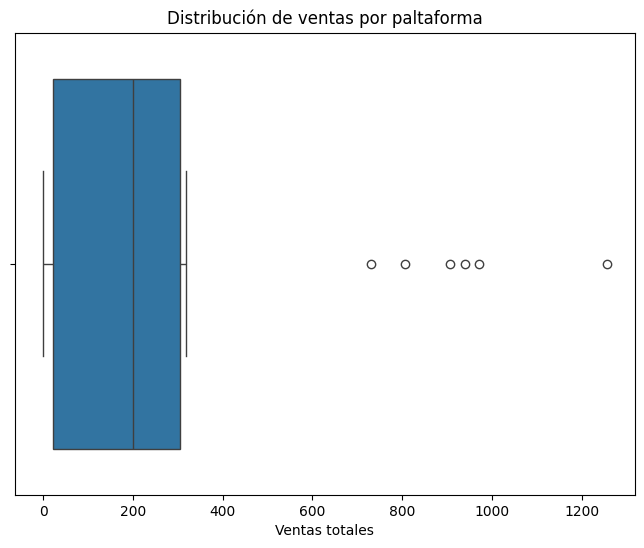

In [17]:
# Se crea una serie con las ventas totales por plataforma
df_diagrama_caja = df.groupby('platform')['total_sales'].sum()
# Se crea el diagrama de caja
plt.figure(figsize=(8,6))
sns.boxplot(x=df_diagrama_caja)
plt.title('Distribución de ventas por paltaforma')
plt.xlabel('Ventas totales')

Si son significativas la diferencia en ventas dependiendo la plataforma. La mediana de ventas es de 200, sin embargo existen algunas plataformas que vendieron mucho mas que eso, estos valores se consideran atipicos ya que su venta es varias veces superior al valor maximo.

<Axes: title={'center': 'Reseña de los ususarios'}, xlabel='Puntuación', ylabel='Ventas'>

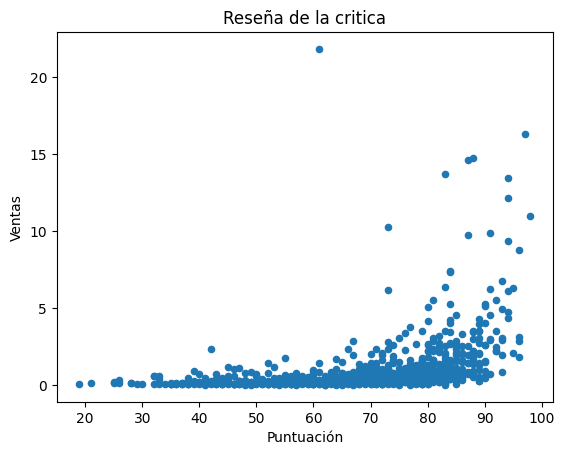

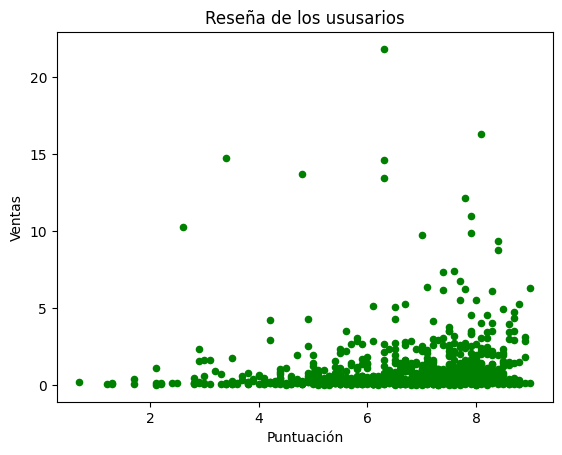

In [18]:
# Se crea un DF que contiene solo la informacion del X360
df_X360 = df[df['platform']=='X360']
# Se crea una gráfica de dispersión para la puntuación de la critica
df_X360.plot(x='critic_score', y='total_sales', kind='scatter', title= 'Reseña de la critica',
            xlabel = 'Puntuación',
            ylabel = 'Ventas')
# Se crea otra gráfica de dispersión para la puntuación de los usuarios
df_X360.plot(x='user_score', y='total_sales', kind='scatter', color = 'green', title= 'Reseña de los ususarios',
            xlabel = 'Puntuación',
            ylabel = 'Ventas')

La puntuación de los usuarios no afecta a las ventas, existen muchos juegos que a pesar de tener una gran puntuación casi no tienen ventas. Sin embargo la puntuación de los criticos si afecta a las ventas, aunque no sea muy nototrio si hay una relación, sobretodo con los juegos que obtuvieron una puntuación superior a 90.

In [19]:
# Elegimos 3 consolas
platforms_to_compare = ['X360','PS3','Wii']
# Elegimos 3 juegos que aparecen en las 3 consolas elegidas
games_to_compare = ['Just Dance 4','Call of Duty: Modern Warfare 3','LEGO Star Wars: The Complete Saga']
# Nos quedamos con un data frame que solo tiene los nombres de los juegos elegidos y estan en las consolas elegidas
df_games_to_compare = df[df['name'].isin(games_to_compare)]
df_platforms_games = df_games_to_compare[df_games_to_compare['platform'].isin(platforms_to_compare)]

# lo agrupamos por nombre y plataforma y mostramos las ventas totales
print(df_platforms_games.groupby(['name', 'platform'])['total_sales'].sum())

name                               platform
Call of Duty: Modern Warfare 3     PS3         13.33
                                   Wii          0.83
                                   X360        14.73
Just Dance 4                       PS3          0.43
                                   Wii          6.76
                                   X360         1.18
LEGO Star Wars: The Complete Saga  PS3          2.28
                                   Wii          5.63
                                   X360         2.58
Name: total_sales, dtype: float64


Se puede apreciar como cambian las ventas dependiendo de la plataforma, el call of duty se vendio muy bien en X3600 y en PS3, pero se vendio muy poco en Wii, posiblemente porque es una consola enfocada principalmente para niños. El Just Dance se vendio principalmente en Wii se vendio menos para X360 y casi nada para el PS3. El juego de LEGO Star Wars se vendio igual en X360 y en PS3, pero en el Wii se vendio mas que en ambas consolas juntas

In [20]:
# Se agrupa por genero y se muestra la suma de las ventas globales
print(df.groupby('genre')['total_sales'].sum().sort_values(ascending = False))
# Se agrupa por genero y se muestra el promedio de las ventas globales
print(df.groupby('genre')['total_sales'].mean().sort_values(ascending = False))

genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: total_sales, dtype: float64
genre
Platform        0.932173
Shooter         0.795503
Role-Playing    0.623872
Racing          0.583403
Sports          0.566980
Fighting        0.527126
Action          0.517711
Misc            0.458577
Simulation      0.446701
Puzzle          0.418224
Strategy        0.255095
Adventure       0.182341
Name: total_sales, dtype: float64


El genero si afecta considerablemente a la rentabilidad de un juego. Los juegos de estrategia, puzzle y Aventura son de los que menos ventas generan tanto en total como en promedio. Existe una diferencia de generos dependiendo si se toma las ventas totales o el promedio de las ventas, por ejemplo el promedio de los juegos de plataforma es el mas alto, sin embargo si revisamos las ventas totales esta en 5to lugar. Lo que quiere decir que los juegos de plataforma se venden bien pero no se producen tantos, como por ejemplo los juegos de acción, que tienen la mayor cantidad de ventas totales pero en promedio generan menos que otros generos. 

In [21]:
# Se agrupa por plataforma y se suman las ventas de las determinadas regiones, y se ordenan
na_platforms = df.groupby('platform')['na_sales'].sum().sort_values(ascending = False)
eu_platforms = df.groupby('platform')['eu_sales'].sum().sort_values(ascending = False)
jp_platforms = df.groupby('platform')['jp_sales'].sum().sort_values(ascending = False)

# Se muestran las 5 primeras, es decir las 5 mas vendidas
print(na_platforms.head(5))
print(eu_platforms.head(5))
print(jp_platforms.head(5))

platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


El X360 tiene la mayor cantidad de ventas en Norteamerica, tiene varias ventas en Europa siendo la tercera plataforma mas vendida, pero no aparece en las principales consolas de Japon, es muy probable que los japoneses tienden a comprar consolas nacionales principalmente. Tambien nos podemos percatar de que los japoneses suelen comprar mas consolas portatiles, ya que la consola mas vendida es el DS y el 3DS se encuentra en la 5 posición, mientras que en Norteamerica el DS se encuentra en la posicion 5 y en Europa no aparece en el top 5 de consolas mas vendidas. En Europa es muy popular Play Station, ya que las dos plataformas con mas ventas son de esta empresa.

In [22]:
# Se agrupa por genero y se suman las ventas de las determinadas regiones, y se ordenan
na_genres = df.groupby('genre')['na_sales'].sum().sort_values(ascending = False)
eu_genres = df.groupby('genre')['eu_sales'].sum().sort_values(ascending = False)
jp_genres = df.groupby('genre')['jp_sales'].sum().sort_values(ascending = False)

# Se muestran los 5 primeros, es decir los 5 generos mas vendidos
print(na_genres.head(5))
print(eu_genres.head(5))
print(jp_genres.head(5))

genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64
genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64
genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


Los mercados de Norteamerica y Europa se ven muy similares, los 3 generos mas populares en estas regiones son Action, Sport, Shooter. En Japon el genero mas famoso es el de Role-Playing, un genero que en las otras regiones ni aparece entre los principales. Los generos de Action y sport tambien tienen grandes ventas en Japon, sin embargo la de shooters no es tan popular.En Europa les gusta mas los juegos de carreras teniendo la posicion 4, mientras que en las otras regiones no aparece. En Norteamerica y en Japon un genero importante es el de platform, que los dos se encuentran en la posicion 4. Los generos de Misc, aparecen en todas las regiones en la posicion numero 5. 

In [23]:
na_genres = df_for_2017.groupby('rating')['na_sales'].sum().sort_values(ascending = False)
eu_genres = df_for_2017.groupby('rating')['eu_sales'].sum().sort_values(ascending = False)
jp_genres = df_for_2017.groupby('rating')['jp_sales'].sum().sort_values(ascending = False)

print(na_genres)
print(eu_genres)
print(jp_genres)

rating
M       555.48
T       295.84
E       276.31
E10+    141.89
K-A       2.30
EC        0.09
RP        0.00
Name: na_sales, dtype: float64
rating
M       390.00
E       204.01
T       197.63
E10+     89.19
K-A       0.11
RP        0.08
EC        0.00
Name: eu_sales, dtype: float64
rating
T       45.70
M       39.72
E       38.81
E10+     9.48
EC       0.00
K-A      0.00
RP       0.00
Name: jp_sales, dtype: float64


Si afecta a las ventas, EC, K-A y RP, tienen muy pocas ventas en cualquier region. Los juegos EC estan enfocados para niños muy pequeños, K-A ya no se ocupa, y Rp son los juegos que no se a definido el raiting. Posiblemente existen muy pocos juegos con estos tipos de clasificaciones, lo que explica sus pocas ventas. Del resto de las clasificaciones E10+ son en las 3 regiones los juegos menos vendidos, teniendo la posicion 4. La calificacion M es la mas vendida en Norteamerica y Europa, mientras que en Japon es la T.

In [24]:
# Hipótesis nula: 'Las calidicaciones promedio de los ususarios para las plataformas XBOX One y PC son las mismas'
# Hipotesis alternativa: 'Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes'

#Elegimos un alpha de 0.05
alpha = 0.05

# Obtenemos el user score de ambas plataformas
average_user_score_Xbox = df[df['platform'] == 'XOne']['user_score']
average_user_score_PC = df[df['platform']=='PC']['user_score']

# Eliminamos los valores ausentes
average_user_score_Xbox = average_user_score_Xbox.dropna()
average_user_score_PC = average_user_score_PC.dropna()

#Se comparan las dos poblaciones y obtenemos el valor p
results_average_user_score = st.ttest_ind(average_user_score_Xbox, average_user_score_PC)
print('valor p: ', results_average_user_score.pvalue)

#Se compara el valor p con el valor elegido de alpha
if results_average_user_score.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
    print("Se acepta la hipótesis alternativa")
else:
    print("No podemos rechazar la hipótesis nula")
    print("No se puede aceptar la hipótesis alternativa")


valor p:  1.3896435533548829e-05
Rechazamos la hipótesis nula
Se acepta la hipótesis alternativa


La hipótesis que nos proporcionan es la hipótesis nula ya indica que entre las dos plataformas no hay diferencia, la hipótesis alternativa es lo contrario.

Se calcula el valor P entre las dos plataformas, como el valor es inferior al alpha que determinamos, se puede rechazar la hipótesis nula.

In [25]:
# Hipótesis alternativa: 'Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes'
# Hipotesis nula: 'Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales'

#Elegimos un alpha de 0.05
alpha = 0.05
 
# Obtenemos el user score de ambas plataformas
average_user_score_Action = df[df['genre'] == 'Action']['user_score']
average_user_score_Sports = df[df['genre']=='Sports']['user_score']

# Eliminamos los valores ausentes
average_user_score_Action = average_user_score_Action.dropna()
average_user_score_Sports = average_user_score_Sports.dropna()

#Se comparan las dos poblaciones y obtenemos el valor p
results_average_user_score_genre = st.ttest_ind(average_user_score_Action, average_user_score_Sports)
print('valor p: ', results_average_user_score_genre.pvalue)

#Se compara el valor p con el valor elegido de alpha
if results_average_user_score_genre.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
    print("Se acepta la hipótesis alternativa")
else:
    print("No podemos rechazar la hipótesis nula")
    print("No se puede aceptar la hipótesis alternativa")

valor p:  0.10406951359049145
No podemos rechazar la hipótesis nula
No se puede aceptar la hipótesis alternativa


En este caso la hipótesis que se proporciono es la hipótesis alternativa, ya que indica que existe una diferencia entre ambos generos.

Se calcula el valor P entre los dos generos, como el valor P es superior al alpha que determinamos, no se puede aceptar la hipótesis alternativa.

    Conclusiones

Para hacer calculos correctamente de esta base de datos, se necesito limpiar los datos, eliminando errores y valores ausentes. Convertir datos para poder utilizarlos en los calculos y agregar una columna extra con las ventas globales.

Lo que se descubrio fue lo siguiente:

1- Las plataformas tienden a durar 9-10 años en el mercado, tardando un año en producir ventas significativas y 5-6 años desde que empiezan a bajar las ventas hasta que se detienen.

2- El x360 y el PS3 ya estan en sus ultimos momentos de vida, es posible que el siguiente año no se venda nada o sea minima la venta. El PS4, Xbox One y 3DS todavía tienen unos años de vida, sin embargo la venta de los 3 ha caido, principalmente la del 3DS. Esto puede ser porque la tienda esta vendiendo cada vez menos o porque faltan los datos de los ultimos meses del 2016.

3- Existe una gran diferencia entre las ventas promedio dependiendo la plataforma, ya que las plataformas que mas venden venden multiples veces la cantidad de la mayoría.

4- La puntuación de los usuarios no afecta a las ventas, pero la puntuacion de los criticos si afecta.

5- La venta de un juego en especifico cambia mucho dependiendo la plataforma, por las cualidades de cada plataforma, estas tienen un publico distinto que a su vez prefiere un determinado tipo de juegos.

6- El genero si afecta considerablemente a la rentabilidad de un juego.

7- Las plataformas venden diferente en cada region, los japoneses tienden a comprar plataformas nacionales y portatiles, en Norteamerica se consume mas juegos de Xbox, y en Europa prefieren plataformas de PlayStation.

8- Los generos de Acción y deportes son de los que mas se venden, en Norteamerica y Europa son los dos generos mas jugados y en japon solo los juegos de rol venden mas.

9- Las calificaciones de ESRB afectan las ventas, EC, K-A y RP tienen casi nada de ventas, posiblemente no muchos juegos tengan estas calificaciones. T, M, y E son los que mas se venden, no existe una diferencia muy grande entre cada una, pero las diferencias si dependen de la region. E10+ se venden menos que T, M y E, sin embargo estos valores no son tan insignificantes.

10- Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes